# Training Playground
This notebook effectively trains LightGBM models for 'Entry' and 'Exit' cues.
It implements:
1. Strict **Track-Level Splitting** to prevent data leakage.
2. **Feature Selection** based on previous analysis (Tier 1-3).
3. **Training Visualization** (Learning Curves: Loss & AUC).
4. **Evaluation Metrics** (Confusion Matrix, ROC-AUC).

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Add src to path to import local modules
sys.path.append('..')
from track import Track
from features import FeatureExtractor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Extract Features
We use the finalized `FeatureExtractor` class to load data. 

In [2]:
data_dir = Path("../../data/processed")
pkl_files = list(data_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} processed tracks.")

all_features = []
all_labels = []

for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            t = pickle.load(f)
            if t.num_bars > 0:
                # Features
                df_feats = FeatureExtractor.extract(t)
                
                # Labels
                df_labels = FeatureExtractor.extract_labels(t)
                
                all_features.append(df_feats)
                all_labels.append(df_labels)
    except Exception as e:
        print(f"Error loading {pkl_path.name}: {e}")

# Combine
X_full = pd.concat(all_features, ignore_index=True)
y_full = pd.concat(all_labels, ignore_index=True)

print(f"Total Rows: {len(X_full)}")
display(X_full.head())

Found 65 processed tracks.
Total Rows: 7248


,track_id,bar_index,bar_pos_norm,dist_to_section,phrase_pos,duration,is_4_bar,energy,energy_prev_8,energy_next_8,energy_diff_context,energy_volatility,energy_derivative,beat_strength,harmonic_ratio,vocal_conf,high_band_energy,syncopation,chroma_rel_0,chroma_rel_7
0,Da Hype (Junior Jack Original Club Mix),0,0.000000,139.0,0,564.964717,1,45121.871094,45121.871094,44541.562500,-580.308594,244.595066,0.000000,1.635383,0.446155,0.076276,1546.932983,2.732868,0.561458,0.709883
1,Da Hype (Junior Jack Original Club Mix),1,0.007246,138.0,1,564.964717,0,44636.796875,44879.333984,44562.566406,-316.767578,223.158049,-485.074219,1.586264,0.417681,0.077184,1519.819580,2.732913,0.553019,0.702327
2,Da Hype (Junior Jack Original Club Mix),2,0.014493,137.0,2,564.964717,0,44574.789062,44777.819010,44792.782552,14.963542,219.407881,-62.007812,1.593891,0.327435,0.081009,1507.728516,2.735485,0.553391,0.697426
3,Da Hype (Junior Jack Original Club Mix),3,0.021739,136.0,3,564.964717,0,44615.675781,44737.283203,44805.821289,68.538086,166.338872,40.886719,1.596661,0.249585,0.084492,1517.752686,2.737075,0.549810,0.698714
4,Da Hype (Junior Jack Original Club Mix),4,0.028986,135.0,4,564.964717,1,44965.046875,44782.835938,48379.858594,3597.022656,166.261031,349.371094,1.625157,0.274185,0.083873,1521.914307,2.740269,0.552125,0.689647


## 2. Define Features & Targets
We filter the DataFrame to keep only the features defined in `FeatureExtractor.FEATURES`. This matches our "Tier 1-3" selection from the previous analysis.

In [3]:
SELECTED_FEATURES = FeatureExtractor.FEATURES

# Check if any are missing
missing_feats = set(SELECTED_FEATURES) - set(X_full.columns)
if missing_feats:
    print(f"Warning: Missing features validation: {missing_feats}")
else:
    print(f"All {len(SELECTED_FEATURES)} selected features are present.")

X = X_full[SELECTED_FEATURES]
groups = X_full['track_id'] # For splitting
y_in = y_full['is_cue_in']
y_out = y_full['is_cue_out']

print(f"Feature Matrix Shape: {X.shape}")

All 17 selected features are present.
Feature Matrix Shape: (7248, 17)


## 3. Track-Level Train/Test Split
**Crucial Step:** We must split by `track_id`.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_in, groups=groups))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

# Targets for Entry
y_in_train = y_in.iloc[train_idx]
y_in_val = y_in.iloc[val_idx]

# Targets for Exit
y_out_train = y_out.iloc[train_idx]
y_out_val = y_out.iloc[val_idx]

print(f"Train Set: {len(X_train)} bars ({len(set(groups.iloc[train_idx]))} tracks)")
print(f"Test Set:  {len(X_val)} bars ({len(set(groups.iloc[val_idx]))} tracks)")

Train Set: 5647 bars (52 tracks)
Test Set:  1601 bars (13 tracks)


## 4. Cross-Validation Training

Starting 5-Fold Cross-Validation using BeatBotModel...
Training Entry Model...
Training Exit Model...
Fold 1 | Entry AUC: 0.8656 | Exit AUC: 0.8347
Training Entry Model...
Training Exit Model...
Fold 2 | Entry AUC: 0.8805 | Exit AUC: 0.7673
Training Entry Model...
Training Exit Model...
Fold 3 | Entry AUC: 0.9002 | Exit AUC: 0.7740
Training Entry Model...
Training Exit Model...
Fold 4 | Entry AUC: 0.9084 | Exit AUC: 0.7701
Training Entry Model...
Training Exit Model...
Fold 5 | Entry AUC: 0.8653 | Exit AUC: 0.7735


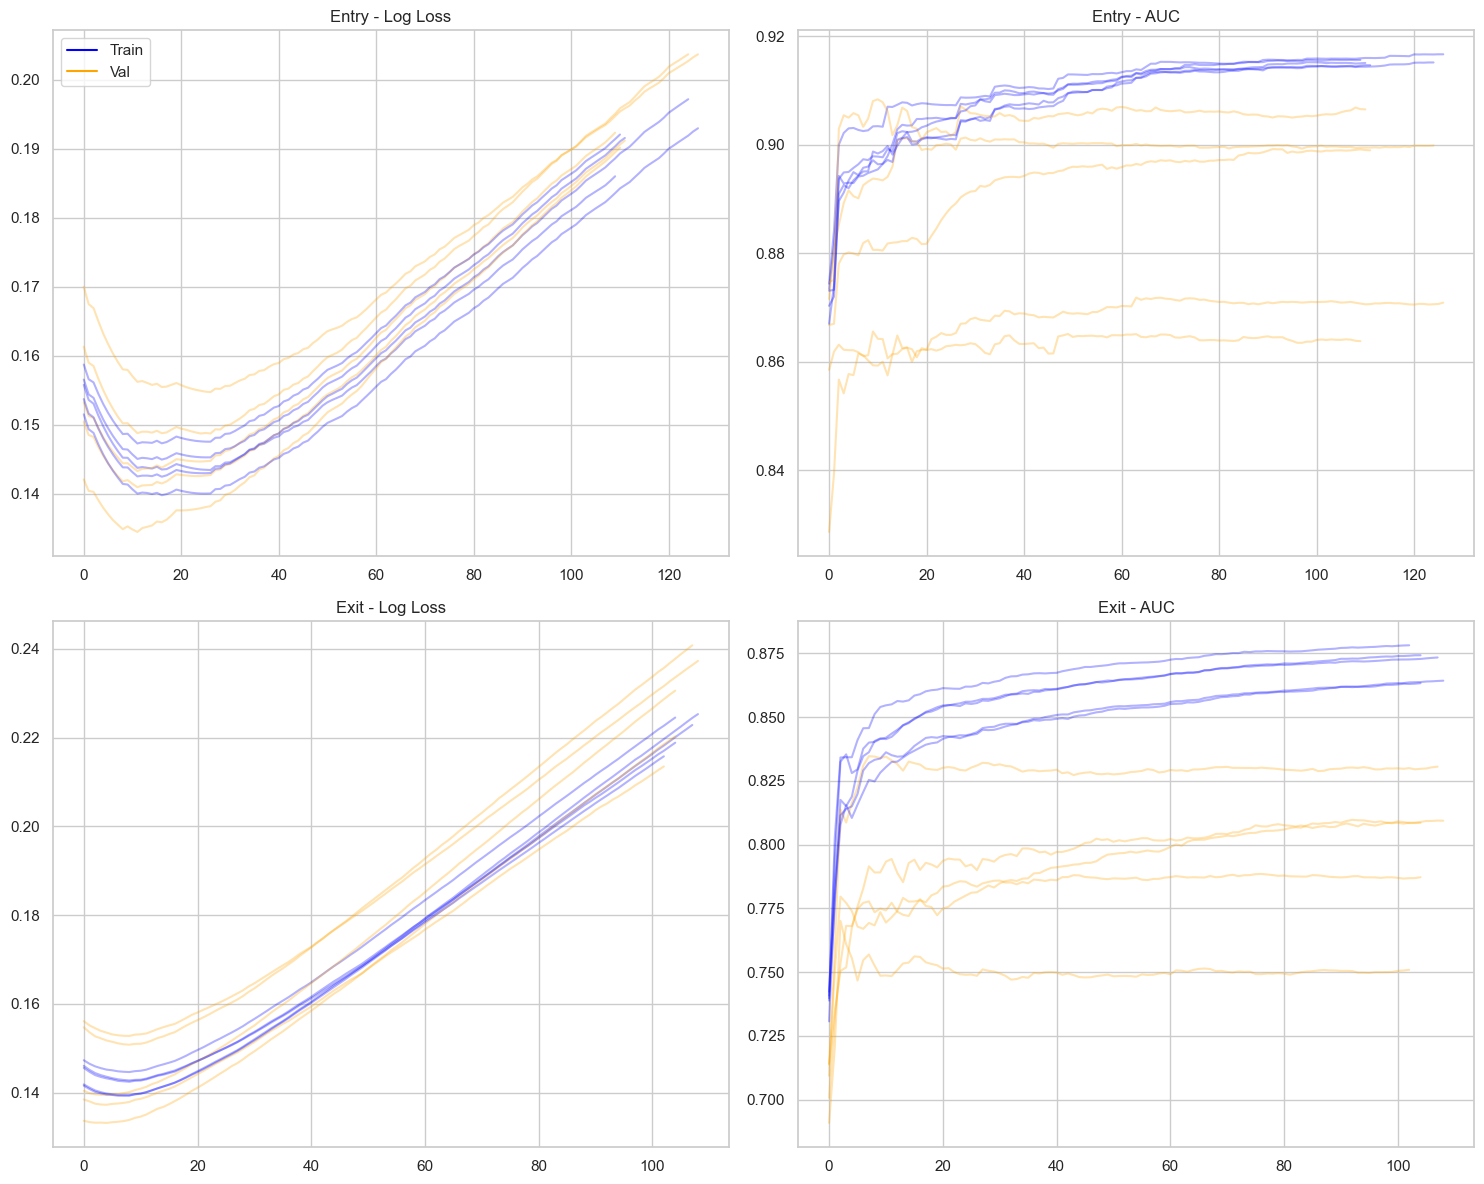


--- CV Results ---
Entry AUC: 0.8840 +/- 0.0177
Exit AUC:  0.7839 +/- 0.0255


In [5]:
# 4. Cross-Validation Training
from model.lightgbm import BeatBotModel

def train_cv(X, y_in, y_out, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    
    fold_aucs_in = []
    fold_aucs_out = []
    
    # Store the best model instance
    best_model = None
    best_avg_auc = -1
    
    fig, ax = plt.subplots(2, 2, figsize=(15, 12)) # 2x2 for Entry/Exit x Loss/AUC
    
    print(f"Starting {n_splits}-Fold Cross-Validation using BeatBotModel...")

    # Iterate through folds
    for i, (train_idx, val_idx) in enumerate(gkf.split(X, y_in, groups=groups)):
        # Prepare Data for this fold
        X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_in_tr, y_in_v = y_in.iloc[train_idx], y_in.iloc[val_idx]
        y_out_tr, y_out_v = y_out.iloc[train_idx], y_out.iloc[val_idx]
        
        # Instantiate OUR model class
        bb_model = BeatBotModel()
        
        # Train on this fold AND PASS VALIDATION DATA
        # This triggers 'eval_set' inside the model class
        history = bb_model.fit(
            X_tr, y_in_tr, y_out_tr, 
            X_val=X_v, 
            y_in_val=y_in_v, 
            y_out_val=y_out_v
        )
        
        # --- Plot Entry Curves (Top Row) ---
        if 'entry' in history and history['entry']:
            res = history['entry']
            epochs = len(res['Train']['binary_logloss'])
            x_axis = range(0, epochs)
            
            # Loss
            ax[0, 0].plot(x_axis, res['Train']['binary_logloss'], alpha=0.3, color='blue')
            ax[0, 0].plot(x_axis, res['Val']['binary_logloss'], alpha=0.3, color='orange')
            
            # AUC
            ax[0, 1].plot(x_axis, res['Train']['auc'], alpha=0.3, color='blue')
            ax[0, 1].plot(x_axis, res['Val']['auc'], alpha=0.3, color='orange')

        # --- Plot Exit Curves (Bottom Row) ---
        if 'exit' in history and history['exit']:
            res = history['exit']
            epochs = len(res['Train']['binary_logloss'])
            x_axis = range(0, epochs)
            
            # Loss
            ax[1, 0].plot(x_axis, res['Train']['binary_logloss'], alpha=0.3, color='blue')
            ax[1, 0].plot(x_axis, res['Val']['binary_logloss'], alpha=0.3, color='orange')
            
            # AUC
            ax[1, 1].plot(x_axis, res['Train']['auc'], alpha=0.3, color='blue')
            ax[1, 1].plot(x_axis, res['Val']['auc'], alpha=0.3, color='orange')
        
        # Evaluate Best AUC (using the model's prediction)
        prob_in_v = bb_model.entry_model.predict_proba(X_v)[:, 1]
        prob_out_v = bb_model.exit_model.predict_proba(X_v)[:, 1]
        
        score_in = roc_curve(y_in_v, prob_in_v)[1] if len(np.unique(y_in_v)) > 1 else 0.5
        score_in_auc = auc(roc_curve(y_in_v, prob_in_v)[0], roc_curve(y_in_v, prob_in_v)[1])
        fold_aucs_in.append(score_in_auc)

        score_out_auc = auc(roc_curve(y_out_v, prob_out_v)[0], roc_curve(y_out_v, prob_out_v)[1])
        fold_aucs_out.append(score_out_auc)
        
        print(f"Fold {i+1} | Entry AUC: {score_in_auc:.4f} | Exit AUC: {score_out_auc:.4f}")
        
        # Track best model
        avg_auc = (score_in_auc + score_out_auc) / 2
        if avg_auc > best_avg_auc:
            best_avg_auc = avg_auc
            best_model = bb_model

    # Finalize Plots
    ax[0, 0].set_title('Entry - Log Loss')
    ax[0, 1].set_title('Entry - AUC')
    ax[1, 0].set_title('Exit - Log Loss')
    ax[1, 1].set_title('Exit - AUC')
    
    # Add dummy legend to one plot
    ax[0, 0].plot([], [], color='blue', label='Train')
    ax[0, 0].plot([], [], color='orange', label='Val')
    ax[0, 0].legend()
    
    plt.tight_layout()
    plt.show()

    print(f"\n--- CV Results ---")
    print(f"Entry AUC: {np.mean(fold_aucs_in):.4f} +/- {np.std(fold_aucs_in):.4f}")
    print(f"Exit AUC:  {np.mean(fold_aucs_out):.4f} +/- {np.std(fold_aucs_out):.4f}")
    
    return best_model

# Reload module to get changes
import importlib
import model.lightgbm
importlib.reload(model.lightgbm)
from model.lightgbm import BeatBotModel

# Run CV using the class
final_model = train_cv(X, y_in, y_out, groups)

## 5. Evaluation on Test Set
Let's see the confusion matrix and ROC curves for the validation set.

--- Classification Report: Entry Cue (Best Fold Validation) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1534
           1       0.00      0.00      0.00        67

    accuracy                           0.96      1601
   macro avg       0.48      0.50      0.49      1601
weighted avg       0.92      0.96      0.94      1601

--- Confusion Matrix: Entry Cue (Best Fold Validation) ---
TN: 1534 | FP: 0
FN: 67 | TP: 0
[[1534    0]
 [  67    0]]


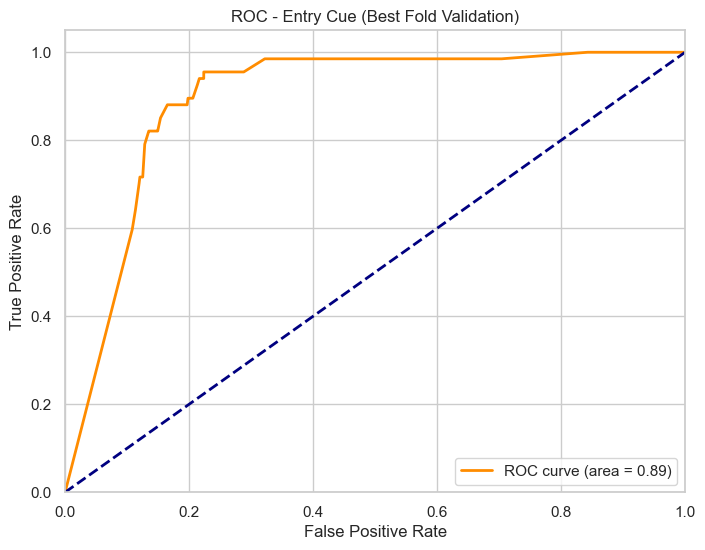

--- Classification Report: Exit Cue (Best Fold Validation) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1552
           1       0.00      0.00      0.00        49

    accuracy                           0.97      1601
   macro avg       0.48      0.50      0.49      1601
weighted avg       0.94      0.97      0.95      1601

--- Confusion Matrix: Exit Cue (Best Fold Validation) ---
TN: 1552 | FP: 0
FN: 49 | TP: 0
[[1552    0]
 [  49    0]]


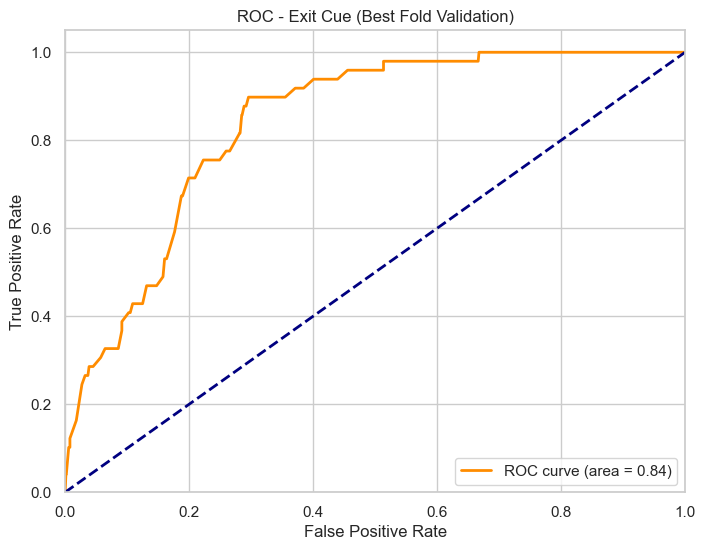

In [6]:
def evaluate_model(model, X_v, y_v, title="Entry"):
    preds_proba = model.predict_proba(X_v)[:, 1]
    preds_class = model.predict(X_v)
    
    print(f"--- Classification Report: {title} ---")
    print(classification_report(y_v, preds_class, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_v, preds_class)
    print(f"--- Confusion Matrix: {title} ---")
    print(f"TN: {cm[0][0]} | FP: {cm[0][1]}")
    print(f"FN: {cm[1][0]} | TP: {cm[1][1]}")
    print(cm)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_v, preds_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {title}')
    plt.legend(loc="lower right")
    plt.show()

# Since we used the FULL dataset in regular CV, let's verify on X_val/X_train slices defined earlier
# (Note: X_val might overlap with training folds of the 'best_model', so take this with a grain of salt)
# Ideally, we'd have a hold-out test set completely separate from CV.
evaluate_model(final_model.entry_model, X_val, y_in_val, "Entry Cue (Best Fold Validation)")
evaluate_model(final_model.exit_model, X_val, y_out_val, "Exit Cue (Best Fold Validation)")

## 6. Feature Importance of Final Models
Double check that `bar_pos_norm` and `energy_diff` are still driving the decisions.

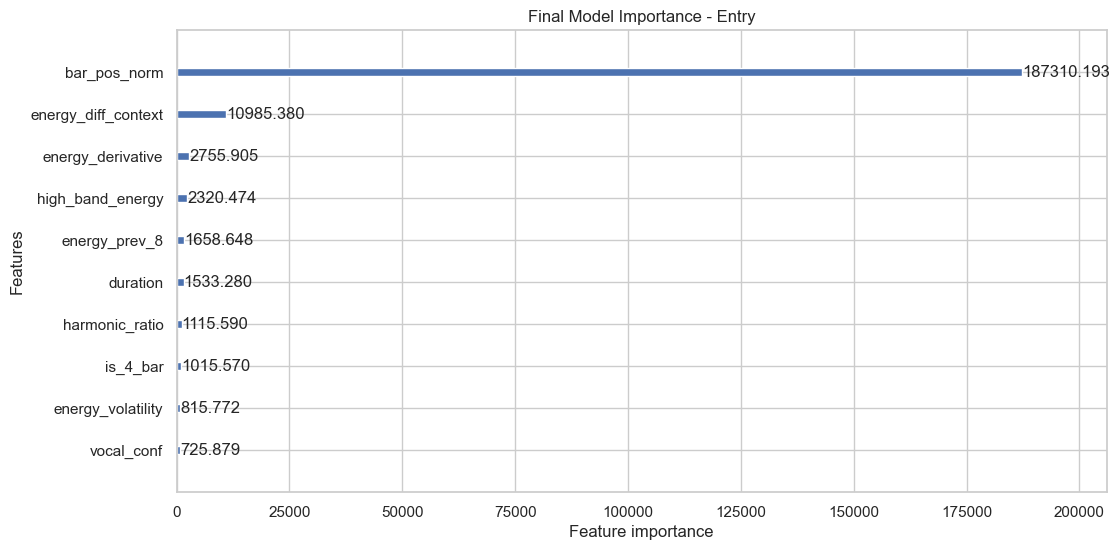

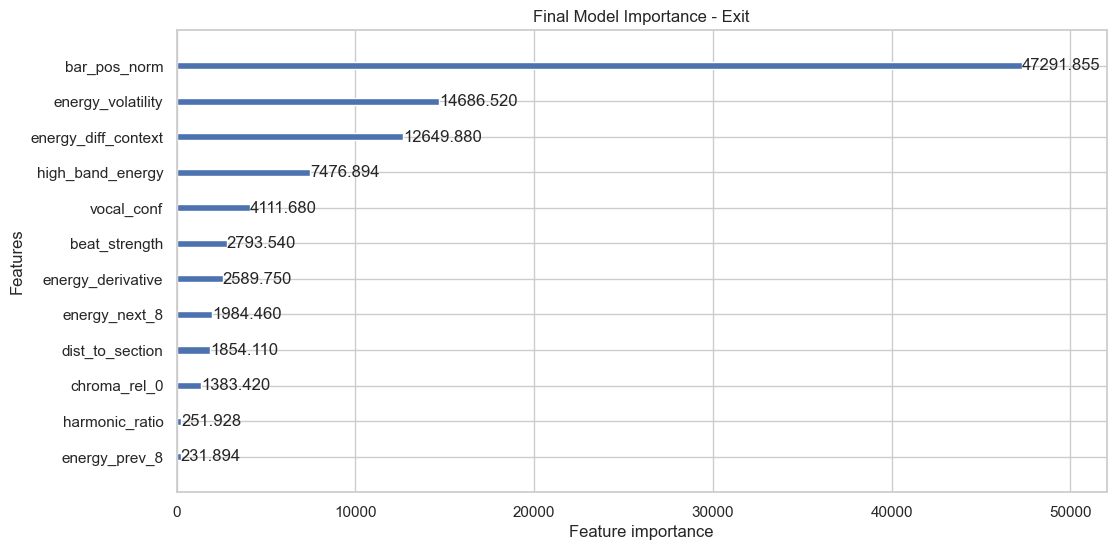

In [7]:
# 7. Feature Importance
lgb.plot_importance(final_model.entry_model, importance_type='gain', max_num_features=15, title='Final Model Importance - Entry')
plt.show()

lgb.plot_importance(final_model.exit_model, importance_type='gain', max_num_features=15, title='Final Model Importance - Exit')
plt.show()

## 7. Try predictions on Actual Data Using Model

Testing new Top-3 Inference on: (2012) Bang The Party - Bang Bang You're Mine [Tom Moulton Edit RMX].mp3
Smart Prediction Result (Top 3):
Entry: [{'bar_index': 25, 'probability': 0.07579067261340043, 'timestamp': 81.67619047619047}, {'bar_index': 45, 'probability': 0.07579067261340043, 'timestamp': 145.2059863945578}, {'bar_index': 80, 'probability': 0.05861832389655864, 'timestamp': 252.4473469387755}]
Exit: [{'bar_index': 267, 'probability': 0.06285070135697532, 'timestamp': 824.587029478458}, {'bar_index': 239, 'probability': 0.06076061826513107, 'timestamp': 738.8125170068028}, {'bar_index': 144, 'probability': 0.0575370378040544, 'timestamp': 450.95473922902494}]
Ground Truth (Bar Indices) - In: [5, 15, 25, 33, 5, 15, 25, 5, 15], Out: [267, 134, 267, 198]


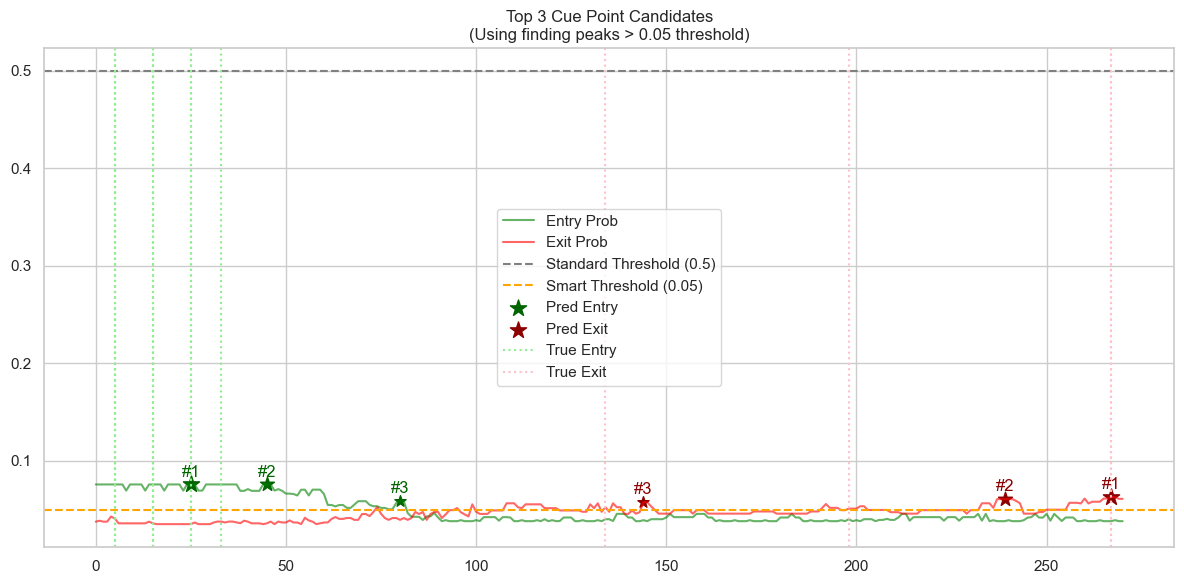

In [15]:
import importlib
import model.lightgbm
importlib.reload(model.lightgbm)
from model.lightgbm import BeatBotModel
from scipy.signal import find_peaks

# Pick a sample track to test the "Smart Inference"
if not pkl_files:
    print("No pkl files found. Make sure you ran the previous cells.")
else:
    test_pkl = pkl_files[10]
    with open(test_pkl, 'rb') as f:
        sample_track = pickle.load(f)

    # Convert Path to string for display if needed
    track_name = sample_track.audio_path.name if sample_track.audio_path else sample_track.track_id
    print(f"Testing new Top-3 Inference on: {track_name}")

    # Create model and copy the trained boosters
    smart_model = BeatBotModel()
    smart_model.entry_model = final_model.entry_model
    smart_model.exit_model = final_model.exit_model

    # Run the smart prediction (getting top 3) WITH LOWER THRESHOLD (0.05)
    cues = smart_model.predict_cue_points(sample_track, top_k=3, threshold=0.05, min_dist_bars=16) 
    print("Smart Prediction Result (Top 3):")
    print("Entry:", cues['cue_in'])
    print("Exit:", cues['cue_out'])

    # Compare with Ground Truth
    # Convert timestamps to bar indices
    true_in_bars = []
    if len(sample_track.cue_in) > 0:
        idxs = np.searchsorted(sample_track.bars, sample_track.cue_in)
        true_in_bars = np.clip(idxs, 0, sample_track.num_bars - 1).tolist()

    true_out_bars = []
    if len(sample_track.cue_out) > 0:
        idxs = np.searchsorted(sample_track.bars, sample_track.cue_out)
        true_out_bars = np.clip(idxs, 0, sample_track.num_bars - 1).tolist()
        
    print(f"Ground Truth (Bar Indices) - In: {true_in_bars}, Out: {true_out_bars}")

    # Visual Proof
    probs = smart_model.predict_track(sample_track)
    plt.figure(figsize=(12, 6))
    plt.plot(probs['bar_index'], probs['prob_in'], label='Entry Prob', color='green', alpha=0.6)
    plt.plot(probs['bar_index'], probs['prob_out'], label='Exit Prob', color='red', alpha=0.6)
    plt.axhline(y=0.5, color='gray', linestyle='--', label='Standard Threshold (0.5)')
    plt.axhline(y=0.05, color='orange', linestyle='--', label='Smart Threshold (0.05)')
    
    # Plot Predicted Candidates
    for i, c in enumerate(cues['cue_in']):
        plt.scatter([c['bar_index']], [c['probability']], color='darkgreen', s=150-(i*40), marker='*', label='Pred Entry' if i==0 else "")
        plt.text(c['bar_index'], c['probability']+0.005, f"#{i+1}", color='darkgreen', ha='center', va='bottom')

    for i, c in enumerate(cues['cue_out']):
        plt.scatter([c['bar_index']], [c['probability']], color='darkred', s=150-(i*40), marker='*', label='Pred Exit' if i==0 else "")
        plt.text(c['bar_index'], c['probability']+0.005, f"#{i+1}", color='darkred', ha='center', va='bottom')
    
    # Plot Ground Truth
    for t_in in true_in_bars:
        plt.axvline(x=t_in, color='lightgreen', linestyle=':', label='True Entry')
    for t_out in true_out_bars:
        plt.axvline(x=t_out, color='pink', linestyle=':', label='True Exit')
        
    # Deduplicate legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    
    plt.title(f"Top 3 Cue Point Candidates\n(Using finding peaks > 0.05 threshold)")
    plt.tight_layout()
    plt.show()

## 8. Save models and Metrics

In [16]:
import json
import os
from datetime import datetime

# 8. Save Models and Metrics
def save_artifacts(final_model, X_v, y_in_v, y_out_v, base_dir="../../data/models"):
    # Create a unique subfolder for this run
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(base_dir, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)
    
    # helper to get metrics
    def get_metrics(model, X, y):
        preds_proba = model.predict_proba(X)[:, 1]
        preds_class = model.predict(X)
        rpt = classification_report(y, preds_class, output_dict=True, zero_division=0)
        fpr, tpr, _ = roc_curve(y, preds_proba)
        roc_auc = auc(fpr, tpr)
        
        # Safely access class "1" metrics
        metrics_class_1 = rpt.get("1", rpt.get("True", {"precision": 0, "recall": 0, "f1-score": 0}))
        
        return {
            "accuracy": rpt["accuracy"],
            "precision_1": metrics_class_1["precision"],
            "recall_1": metrics_class_1["recall"],
            "f1_1": metrics_class_1["f1-score"],
            "auc": roc_auc
        }

    # Calculate metrics
    metrics_in = get_metrics(final_model.entry_model, X_v, y_in_v)
    metrics_out = get_metrics(final_model.exit_model, X_v, y_out_v)
    
    evaluation_data = {
        "timestamp": timestamp,
        "entry_model": metrics_in,
        "exit_model": metrics_out,
        "features": SELECTED_FEATURES
    }
    
    # Save Metrics
    json_path = os.path.join(run_dir, "evaluation.json")
    with open(json_path, "w") as f:
        json.dump(evaluation_data, f, indent=4)
    print(f"Metrics saved to: {json_path}")
    
    # Save Feature Importance Plot
    # (Optional but useful)
    
    # Save Full Model Object (The Class)
    model_path = os.path.join(run_dir, "beatbot_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(final_model, f)
    print(f"Full BeatBotModel saved to: {model_path}")

    return run_dir

# Run the save
last_run_dir = save_artifacts(final_model, X_val, y_in_val, y_out_val)
print(f"Run completed. Artifacts in {last_run_dir}")

Metrics saved to: ../../data/models/run_20260216_161501/evaluation.json
Full BeatBotModel saved to: ../../data/models/run_20260216_161501/beatbot_model.pkl
Run completed. Artifacts in ../../data/models/run_20260216_161501
